In [1]:
import os
import sys
import random
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import mlflow

import tensorflow as tf
from tensorflow.keras import Model, Sequential, layers
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose, Flatten 

2025-11-28 10:48:44.672253: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
sys.stderr = open(os.devnull, "w")

I0000 00:00:1764323520.961190    1652 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46640 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:81:00.0, compute capability: 8.6
2025-11-28 10:52:37.467149: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2025-11-28 10:55:03.531349: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-28 11:03:49.443202: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-28 11:05:43.604779: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-28 11:08:59.860540: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-28 11:15:48.652204: I tensorflow/

# Dataloading

In [3]:
notebook_dir = Path().resolve()  # current working directory
parent_dir = notebook_dir.parent
sys.path.insert(0, str(parent_dir))

from Data.DataLoader_GPUnet import DataLoader_GPUnet
from Data.DataGenerator import DataGenerator
from Helpers import Helpers
Helpers = Helpers()

In [ ]:
# DataLoader_GPUnet doesn't work here. It was designed for pulling from a specific server
# To do: Implement open DataLoader that pulls images from  "German National Cohort NAKO Conosortium" and labels from "Vibesegmentator: full body mri segmentation for the nako and uk biobank"
datagenerator = DataGenerator(DataLoader_GPUnet(mode='training_combined', val_size=0.05))

going to load 16 items
Xreslicing label, interp. order 0
Xreslicing label, interp. order 0
Xreslicing label, interp. order 0
Xreslicing label, interp. order 0
Xreslicing label, interp. order 0
Xreslicing label, interp. order 0
XXXXXXXXreslicing label, interp. order 0
Xreslicing label, interp. order 0
Xreslicing label, interp. order 0



# Augment Training Data

### Augmentation here in the Notebook, becuase it's the old version

In [6]:
geo_aug = tf.keras.Sequential([
    tf.keras.Input(shape=(128, 128, 4)), 
    layers.RandomFlip("horizontal"), # horizontal_and_vertical
    layers.RandomRotation(0.05, fill_mode="reflect", interpolation="nearest"), # fill_mode="reflect", interpolation="nearest" make the results less blurry
    layers.RandomZoom((-0.05, 0.05), (-0.05, 0.05), fill_mode="reflect", interpolation="nearest"),
    layers.RandomTranslation((-0.05, 0.05), (-0.05, 0.05), fill_mode="reflect", interpolation="nearest"),
])

photo_aug = tf.keras.Sequential([
    layers.RandomBrightness(factor=0.05, value_range=(0, 1)),
    layers.Lambda(lambda x: x + tf.random.uniform(tf.shape(x), -0.05, 0.05)),
    layers.RandomContrast(factor=0.1),
    layers.GaussianNoise(0.03),
])

In [7]:
def cut_out(p_segm, max_fraction_upper=0.25):
    """Simulates user forgetting some pixels"""
    p_eq_1_mask = tf.equal(p_segm, 1)

    # x% to set 1 to 0
    num = random.uniform(0.0, max_fraction_upper)
    random_mask = tf.less(tf.random.uniform(shape=tf.shape(p_segm)), num)
    
    final_mask = tf.logical_and(p_eq_1_mask, random_mask)
    return tf.where(final_mask, tf.constant(0, dtype=p_segm.dtype), p_segm)

# ---------------------------------------------

def add_false_positives(p_segm, max_fraction_upper):
    """
    Simulates user adding too much pixels. Randomly add false positives to the prompt mask.
    max_fraction_upper: maximum fraction of pixels that can be turned on.
    """
    # Sample a random fraction between 0 and max_fraction_upper
    max_fraction = tf.random.uniform([], 0.0, max_fraction_upper)

    background_mask = tf.equal(p_segm, 0)
    random_mask = tf.less(tf.random.uniform(shape=tf.shape(p_segm)), max_fraction)

    add_mask = tf.logical_and(background_mask, random_mask)
    return tf.where(add_mask, tf.constant(1, dtype=p_segm.dtype), p_segm)

# ---------------------------------------------

from scipy.ndimage import label, binary_erosion, binary_dilation

# def tf_dilate(mask, kernel_size=3):
#     mask = Helpers.shaping(mask) # shape(1,x,x,1)
#     k = tf.cast(kernel_size, tf.int32)
#     dilated = tf.nn.max_pool2d(mask, ksize=[1, k, k, 1], strides=[1, 1, 1, 1], padding="SAME")
#     return tf.cast(dilated[0,...], mask.dtype)

# def tf_erode(mask, kernel_size=3):
#     mask = Helpers.shaping(mask) # shape(1,x,x,1)
#     k = tf.cast(kernel_size, tf.int32)
#     eroded = 1.0 - tf.nn.max_pool2d(
#         1.0 - mask, ksize=[1, k, k, 1], strides=[1, 1, 1, 1], padding="SAME"
#     )
#     return tf.cast(eroded[0,...], mask.dtype)

def selective_dilate(mask, kernel_size, min_size):
    """
    Dilate only connected components larger than min_size.
    mask: 2D or 3D numpy array (H, W[, 1])
    """
    # mask = Helpers.shaping(mask) # shape(1,x,x,1)
    mask_2d = np.squeeze(mask)  # drop singleton channel if present
    labeled, num_features = label(mask_2d)
    dilated_mask = mask_2d.copy()

    for i in range(1, num_features + 1):
        component = (labeled == i)
        if np.sum(component) >= min_size:
            structure = np.ones((kernel_size,) * component.ndim)
            dilated_component = binary_dilation(component, structure=structure)
            dilated_mask[dilated_component] = 1  # <— instead of masking with original component

    
    # Add channel back if original mask had one
    if mask.ndim == 3 and mask.shape[2] == 1:
        dilated_mask = dilated_mask[..., np.newaxis]

    return dilated_mask.astype(mask.dtype)

def tf_selective_dilate(mask, kernel_size, min_size):
    # TensorFlow wrapper
    mask_shape = mask.shape
    out = tf.numpy_function(selective_dilate, [mask, kernel_size, min_size], tf.float32)
    out.set_shape(mask.shape)
    return out


# ----

def selective_erode(mask, kernel_size, min_size):
    """
    Erode only connected components larger than min_size.
    mask: 2D or 3D numpy array (H, W, 1)
    """
    # Remove singleton channel dimension
    mask_2d = np.squeeze(mask)
    
    labeled, num_features = label(mask_2d)
    eroded_mask = mask_2d.copy()
    
    for i in range(1, num_features + 1):
        component = (labeled == i)
        if np.sum(component) >= min_size:
            structure = np.ones((kernel_size,) * component.ndim)
            eroded_component = binary_erosion(component, structure=structure)
            eroded_mask[component] = eroded_component[component]
    
    # Add channel back if original mask had one
    if mask.ndim == 3 and mask.shape[2] == 1:
        eroded_mask = eroded_mask[..., np.newaxis]
    
    # tf.expand_dims(x, axis=0)
    
    return eroded_mask.astype(mask.dtype)

def tf_selective_erode(mask, kernel_size, min_size):
    # TensorFlow wrapper
    mask_shape = mask.shape
    eroded = tf.numpy_function(selective_erode, [mask, kernel_size, min_size], tf.float32)
    eroded.set_shape(mask_shape)  # preserve static shape for TF graph
    return eroded

# ----

def random_morphological_perturbation(mask, max_dilate_kernel, max_erode_kernel, min_erode_size, min_dilate_size):
    """
    Randomly apply:
      0 -> Erosion
      1 -> Dilation
    mask: 2D float32 tensor (0/1)
    max_dilate_kernel: How strong can the dilation be?
    max_erode_kernel: How strong can the erosion be?
    min_erode_size: Erosion only works with segments larger than min_erode_size
    min_dilate_size: Dilation only works with segments larger than min_erode_size
    """
    rand_val = tf.random.uniform([], 0, 3, dtype=tf.int32)  # random integer 0,1
    # print(rand_val)
       
    def erode_fn():
        # if k=1 it does nothing
        k = tf.random.uniform([], 1, max_erode_kernel + 1, dtype=tf.int32)  # 1–x
        return tf_selective_erode(mask, kernel_size=k, min_size=min_erode_size)
    
    def dilate_fn():
        k = tf.random.uniform([], 1, max_dilate_kernel + 1, dtype=tf.int32)  # 1–x
        return tf_selective_dilate(mask, kernel_size=k, min_size=min_dilate_size)
    
    def do_nothing():
        return mask
    
    return tf.switch_case(rand_val, branch_fns={
        0: erode_fn,
        1: dilate_fn,
        2: do_nothing
    })

In [8]:
def augmentation(x, y, p):
    """ Photometric augmentations only on x. Geometric augmentations on x,y,p consistently. Prompt augmentations only on p (segmentation).
    """  
    # --- Only x --- 
    if random.random() < 0.1:
        x = photo_aug(x)
        if len(x.shape) > len(y.shape):
            x = x[...,0]
        x = Helpers.min_max_norm(x)

    # --- x,y,p ---
    if random.random() < 0.1:
        concatenated_tensor = tf.concat([x, y, p], axis=-1)
        concatenated_tensor = tf.expand_dims(concatenated_tensor, 0)
        concatenated_tensor = geo_aug(concatenated_tensor)
        concatenated_tensor = concatenated_tensor[0,...]
        x,y,p = tf.split(concatenated_tensor, num_or_size_splits=[1, 1, 2], axis=-1)

    # --- Only p ---
    if random.random() < 0.1:
        p_segm = p[...,1:2]
        p_segm = cut_out(p_segm, max_fraction_upper=0.20)
        p_segm = add_false_positives(p_segm, max_fraction_upper=0.001)
        p_segm = tf.squeeze(p_segm)
        p_segm = random_morphological_perturbation(p_segm, max_dilate_kernel=2, max_erode_kernel=2, min_erode_size=30, min_dilate_size=30)

        p_segm = tf.expand_dims(p_segm, -1)
        p = tf.concat([p[...,0:1], p_segm], axis=-1)
    
    return x, y, p # No batch_dim. When calling .batch() later, it will be added automatically

# Prompt U-Net

In [9]:
batch_size = 128
dp_training = 3500 # be careful, these variables exist twice

steps_per_epoch = dp_training // batch_size  
decay_epochs = 2000  # reduce every x epochs
decay_steps = steps_per_epoch * decay_epochs 

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=decay_steps,  # decay every x epochs
    decay_rate=0.85,                      # halve LR each decay
    staircase=True
)

In [10]:
class PromptUNet():

    def __init__(self):
        self.loss = tf.losses.binary_crossentropy
        self.train_loss = tf.keras.metrics.Mean(name='train_loss')

        self.this = self.build()


    def build(self):
        inputs = [tf.keras.Input(shape=(datagenerator.height, datagenerator.width, 1),name='image'),
                tf.keras.Input(shape=(datagenerator.height, datagenerator.width, 2),name='prompt')]      # u(x, [x+i, y+i]) = y      i = shift (e.g. 3)      [x+i, y+i] = prompt

        image = inputs[0]
        prompt = inputs[1]

        prompt_skip_connections = []
        skip_connections = []


        def conv_block(inp, filters, padding='same', activation='leaky_relu', dropout_rate=0.1, **kwargs):
            """
            Convolution block of UNet encoder
            """
            inp = layers.Conv2D(filters, (3,3), padding=padding, **kwargs)(inp)
            inp = layers.BatchNormalization()(inp)
            inp = layers.LeakyReLU()(inp)
            inp = layers.Dropout(dropout_rate)(inp)
            return inp

        def conv_block_prompt(x, p, filters, padding='same', activation='leaky_relu', dropout_rate=0.1):           
            """
            Convolution block of UNet encoder with conditioning on prompt
            """
            p = conv_block(p, filters)
            x = layers.Conv2D(filters, (3, 3), padding=padding)(x)
            x = layers.Add()([x,p])
            x = layers.Dropout(dropout_rate)(x)
            return x

        def conv_block_up(inp, filters, padding='same', activation='leaky_relu', dropout_rate=0.1, **kwargs):
            """
            Convolution block of UNet encoder
            """
            inp = layers.BatchNormalization()(inp)
            inp = layers.LeakyReLU()(inp)
            inp = layers.Dropout(dropout_rate)(inp)
            inp = Conv2DTranspose(filters, (3,3), padding=padding, **kwargs)(inp)
            return inp

    # ---------------------------------------------- 

        def encoder_block(p, filters, padding='same', activation='leaky_relu'):
            """
            Encoding of prompt
            """
            print("p encode shape:", p.shape)
            p = conv_block(p, filters, padding, activation)
            p = conv_block(p, filters, padding, activation)
            prompt_skip_connections.append(p)
            p = conv_block(p, filters*2, padding, strides=2)
            return p

        def encoder_block_2(x, p, filters, padding='same'):
            """Encoding of x / input image + Conditioning on prompt
            """
            print("x,p shape:", x.shape, p.shape)
            x = conv_block_prompt(x, p, filters)        
            skip_connections.append(x)
            x = conv_block(x, filters*2, padding, strides=2) # Strided conv better then max pooling
            return x

        def decoder_block(inp, concat_layer, filters, padding='same', dropout_rate=0.1):
            """Upsample the feature maps + skip connections
            """
            x = conv_block_up(inp, filters, padding, strides=2)
            print("x,concat shape:", x.shape, concat_layer.shape)
            x = conv_block(x, filters, padding, dropout_rate=dropout_rate)
            x = concatenate([x,concat_layer])      
            x = conv_block(x, filters, padding, dropout_rate=dropout_rate)
            return x


        # --- Encoding prompt ---
        print("--- Encoding prompt ---")
        prompt = Conv2D(32, (3, 3), padding="same")(prompt)
        prompt = encoder_block(prompt,32)
        prompt = encoder_block(prompt,64)
        prompt = encoder_block(prompt,128)
        prompt = encoder_block(prompt,256)
        prompt = encoder_block(prompt,512)
        print()
        print("p encode shape:", prompt.shape, "\n\n")

        # --- Enprompt_skip_connectionsx (with conditioning on prompt) ---
        print("--- Encoding x (with conditioning on prompt) ---")
        x = Conv2D(32, (3, 3), padding="same")(image)
        x = encoder_block_2(x=x, p=prompt_skip_connections.pop(0), filters=32) 
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 64)
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 128)
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 256)
        x = encoder_block_2(x, prompt_skip_connections.pop(0), 512)

        # --- Middle part ---
        print()
        x = conv_block(x, 1024, dropout_rate=0.2)  # Höhere Dropout-Rate im Bottleneck
        print("--- Middle part (not in skip connection) ---")
        print("x shape:", x.shape, "\n\n")
        

        # --- Decoding / Upsampling (with skip connections) ---
        print("--- Decoding / Upsampling (with skip connections) ---") 
        x = decoder_block(x, skip_connections.pop(), 512)
        x = decoder_block(x, skip_connections.pop(), 256)
        x = decoder_block(x, skip_connections.pop(), 128)
        x = decoder_block(x, skip_connections.pop(), 64)
        x = decoder_block(x, skip_connections.pop(), 32)
        print("x shape:", x.shape)


        output = Conv2D(1, 1)(x)                               
        output = tf.keras.activations.sigmoid(output)          

        return tf.keras.Model(inputs=inputs, outputs=output)



    # Doing one training step
    def train_step(self,z):
        with tf.GradientTape() as tape:
            # z shape: (input[batch_size,height,width,1], label[batch_size,height,width,1], prompt[batch_size,height,width,2])
            # 0 = input/x, 1 = label/y, 2 = prompt/p
            y_pred = self.this([z[0], z[2]], training=True)   
            loss = self.loss(z[1], y_pred)

        gradients = tape.gradient(loss, self.this.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.this.trainable_variables))
        self.train_loss(loss)

    # One training epoch
    def train_epoch(self, train_dataset, M=5, batch_size=32):
        """train_dataset = (x_train[num_slices,height,width,1], y_train[num_slices,height,width,1], p_train[num_slices,height,width,2]). Tuple, no list!
        """
        train_dataset = train_dataset.shuffle(256) \
        .map(lambda x, y, p: augmentation(x, y, p), num_parallel_calls=tf.data.AUTOTUNE) \
        .batch(batch_size) \
        .prefetch(tf.data.AUTOTUNE)

        for _ in range(M):
            batch_iter = iter(train_dataset)
            c = 1
        while True:
            z = next(batch_iter, None)
            if z is None:
                break
            self.train_step(z)
            c = c + 1
            print(".",end='')

        
# init model
model = PromptUNet()
model.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

dummy_input = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
dummy_prompt = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([dummy_input, dummy_prompt])


# (batchsize, heigt, width, channels -> image and label for prompt (2), otherwise only image (1))

--- Encoding prompt ---
p encode shape: (None, 128, 128, 32)
p encode shape: (None, 64, 64, 64)
p encode shape: (None, 32, 32, 128)
p encode shape: (None, 16, 16, 256)
p encode shape: (None, 8, 8, 512)

p encode shape: (None, 4, 4, 1024) 


--- Encoding x (with conditioning on prompt) ---
x,p shape: (None, 128, 128, 32) (None, 128, 128, 32)
x,p shape: (None, 64, 64, 64) (None, 64, 64, 64)
x,p shape: (None, 32, 32, 128) (None, 32, 32, 128)
x,p shape: (None, 16, 16, 256) (None, 16, 16, 256)
x,p shape: (None, 8, 8, 512) (None, 8, 8, 512)

--- Middle part (not in skip connection) ---
x shape: (None, 4, 4, 1024) 


--- Decoding / Upsampling (with skip connections) ---
x,concat shape: (None, 8, 8, 512) (None, 8, 8, 512)
x,concat shape: (None, 16, 16, 256) (None, 16, 16, 256)
x,concat shape: (None, 32, 32, 128) (None, 32, 32, 128)
x,concat shape: (None, 64, 64, 64) (None, 64, 64, 64)
x,concat shape: (None, 128, 128, 32) (None, 128, 128, 32)
x shape: (None, 128, 128, 32)


# Training

In [ ]:
epochs = 4200
batch_size = 128

offset = 12
max_number_labels = 4
cropping = True
cropping_composition = 0.7

dp_training = 3500
dp_testing = 1000

new_ds = 75 # Every x Epochs a new DS is generated
new_val_loop = 300 # Every x Epochs the validation loop is performed

version = 'p_unet_21'

Before
Creating new Data Points ...
It took 142 seconds
After


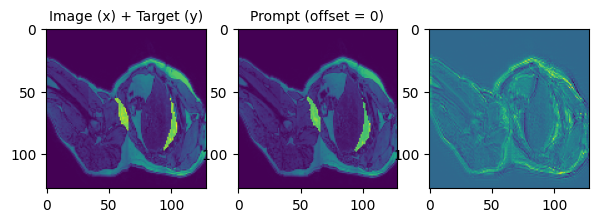

Creating new Data Points ...
It took 342 seconds
Creating new Data Points ...
It took 177 seconds
............................Epoch 1, Loss: 0.47982025146484375, 
............................Epoch 2, Loss: 0.3412860333919525, 
............................Epoch 3, Loss: 0.28336673974990845, 
............................Epoch 4, Loss: 0.24286943674087524, 
............................Epoch 5, Loss: 0.20898382365703583, 
............................Epoch 6, Loss: 0.19041374325752258, 
............................Epoch 7, Loss: 0.17422741651535034, 
............................Epoch 8, Loss: 0.1603759378194809, 
............................Epoch 9, Loss: 0.15398117899894714, 
............................Epoch 10, Loss: 0.14491581916809082, 
............................Epoch 11, Loss: 0.1398468017578125, 
............................Epoch 12, Loss: 0.13478368520736694, 
............................Epoch 13, Loss: 0.1314641237258911, 
............................Epoch 14, Loss: 0.12792007625

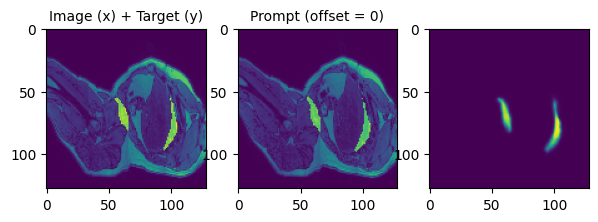

Creating new Data Points ...
It took 419 seconds
Creating new Data Points ...
It took 138 seconds
............................Epoch 76, Loss: 0.09217052906751633, 
............................Epoch 77, Loss: 0.08475326001644135, 
............................Epoch 78, Loss: 0.08279801160097122, 
............................Epoch 79, Loss: 0.08135514706373215, 
............................Epoch 80, Loss: 0.0798860639333725, 
............................Epoch 81, Loss: 0.08020081371068954, 
............................Epoch 82, Loss: 0.07859402149915695, 
............................Epoch 83, Loss: 0.07860052585601807, 
............................Epoch 84, Loss: 0.07593140006065369, 
............................Epoch 85, Loss: 0.0745033323764801, 
............................Epoch 86, Loss: 0.0733073279261589, 
............................Epoch 87, Loss: 0.08501565456390381, 
............................Epoch 88, Loss: 0.07511726021766663, 
............................Epoch 89, Loss: 0.0

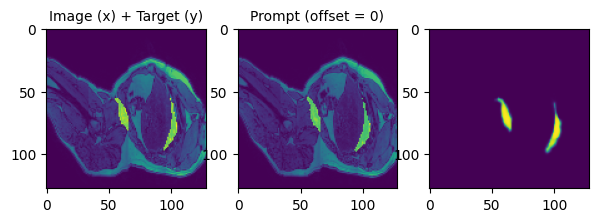

Creating new Data Points ...
It took 354 seconds
Creating new Data Points ...
It took 166 seconds
............................Epoch 151, Loss: 0.09372416138648987, 
............................Epoch 152, Loss: 0.08425432443618774, 
............................Epoch 153, Loss: 0.08659330755472183, 
............................Epoch 154, Loss: 0.07675734907388687, 
............................Epoch 155, Loss: 0.07139775156974792, 
............................Epoch 156, Loss: 0.08460595458745956, 
............................Epoch 157, Loss: 0.0716034397482872, 
............................Epoch 158, Loss: 0.06685683876276016, 
............................Epoch 159, Loss: 0.08514722436666489, 
............................Epoch 160, Loss: 0.06745731085538864, 
............................Epoch 161, Loss: 0.06344517320394516, 
............................Epoch 162, Loss: 0.06060423329472542, 
............................Epoch 163, Loss: 0.05907009541988373, 
............................Epoc

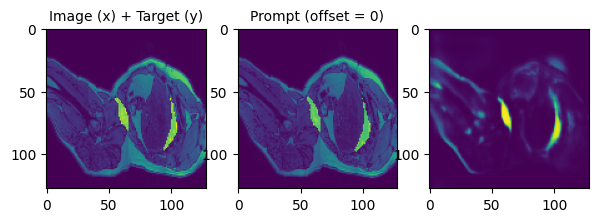

Creating new Data Points ...
It took 279 seconds
Creating new Data Points ...
It took 127 seconds
............................Epoch 226, Loss: 0.08813679218292236, 
............................Epoch 227, Loss: 0.0801234319806099, 
............................Epoch 228, Loss: 0.07556096464395523, 
............................Epoch 229, Loss: 0.07064882665872574, 
............................Epoch 230, Loss: 0.06623249500989914, 
............................Epoch 231, Loss: 0.08455803245306015, 
............................Epoch 232, Loss: 0.06765637546777725, 
............................Epoch 233, Loss: 0.06237540394067764, 
............................Epoch 234, Loss: 0.06197456642985344, 
............................Epoch 235, Loss: 0.058548301458358765, 
............................Epoch 236, Loss: 0.055922459810972214, 
............................Epoch 237, Loss: 0.05306967347860336, 
............................Epoch 238, Loss: 0.053855981677770615, 
............................E

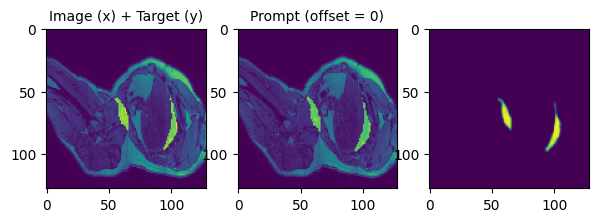

Creating new Data Points ...
It took 368 seconds
Creating new Data Points ...
It took 204 seconds
............................Epoch 301, Loss: 0.08589132130146027, 
............................Epoch 302, Loss: 0.07226090878248215, 
............................Epoch 303, Loss: 0.06782682240009308, 
............................Epoch 304, Loss: 0.0641869306564331, 
............................Epoch 305, Loss: 0.06081311032176018, 
............................Epoch 306, Loss: 0.07169758528470993, 
............................Epoch 307, Loss: 0.059551749378442764, 
............................Epoch 308, Loss: 0.05589301511645317, 
............................Epoch 309, Loss: 0.05341823399066925, 
............................Epoch 310, Loss: 0.05192545801401138, 
............................Epoch 311, Loss: 0.07173818349838257, 
............................Epoch 312, Loss: 0.06834600120782852, 
............................Epoch 313, Loss: 0.07213032990694046, 
............................Epo

In [ ]:
from IPython.display import clear_output

def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run() as run:
        
        # Log hyperparameters
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("max_number_labels", max_number_labels)
        mlflow.log_param("num_epochs", epochs)
        mlflow.log_param("loss_function", "binary_crossentropy")
        
        test_ds, _ = datagenerator.get_val_data_points(max_data_points=dp_testing, offset=offset, max_number_labels=max_number_labels, cropping=False)
        len_test_ds = len(list(test_ds.as_numpy_iterator()))
        
        
        for epoch in range(epochs):  
            # --- Log Lr ---
            current_lr = model.optimizer.learning_rate
            
            if isinstance(current_lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                current_lr = current_lr(epoch)  # evaluate schedule at current epoch
            else:
                current_lr = current_lr.numpy()  # constant value

            mlflow.log_metric("learning_rate", float(current_lr), step=epoch)
            
            model.train_loss = tf.keras.metrics.Mean(name='train_loss')

            if epoch%8==0 and epoch != 0:
                
                model_name = f'{version}.keras'
                model.this.save(model_name)
                #mlflow.log_artifact(model_name, artifact_path="checkpoints")
                
            # Validation Loop
            if epoch%new_val_loop==0 and epoch != 0:
                
                total_dice = 0

                for x_test, y_test, p_test in test_ds:
                    x_test = tf.expand_dims(x_test, axis=0) 
                    p_test = tf.expand_dims(p_test, axis=0)

                    val_pred = model.this([x_test[0:1,:,:,0:1], p_test[0:1,...]])
                    total_dice += Helpers.dice_score_tf(y_test[...,0:1], val_pred)

                total_dice /= len_test_ds
                mlflow.log_metric("validation_loss", 1-total_dice, step=epoch)
                print('Validation loss:', str(1-total_dice))

                
                
            # Pull new random Train Dataset (every x epochs because create_prompt takes some time)
            if epoch%new_ds==0:
                
                # Plot pred for first x examples of val ds
                x_test, y_test, p_test = next(iter(test_ds))
                x_test = tf.expand_dims(x_test, axis=0) 
                p_test = tf.expand_dims(p_test, axis=0)

                pred = model.this([x_test[0:1,:,:,0:1], p_test[0:1,...]])
                Helpers.plot_result(x_test, y_test, p_test, pred, 0, "")
                
                # New Ds
                train_ds, offset_train = datagenerator.get_data_points(max_data_points=dp_training, offset=offset, max_number_labels=max_number_labels, cropping=cropping, cropping_composition=cropping_composition)
                   
                    
            model.train_epoch(train_dataset=train_ds, M=1, batch_size=batch_size)      

            # Display & log metrics at the end of each epoch
            print(f'Epoch {epoch + 1}, '
                  f'Loss: {model.train_loss.result()}, ')
            mlflow.log_metric("train_loss", model.train_loss.result(), step=epoch)
            
        # log the final model
        # mlflow.keras.log_model(model.this, artifact_path="final_model")

fit(epochs)   